### 1.生成数据集

In [211]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs

In [212]:
X, y = make_blobs(
    n_samples=300,           # 生成300个样本
    n_features=2,            # 每个样本包含2个特征
    centers=3,               # 生成3个数据簇
    cluster_std=1,           # 设置各数据簇的标准差为1
    center_box=(-10, 10),    # 将聚类中心限制在-10到10之间
    random_state=233,        # 固定随机结果，保证每次运行结果一致
    return_centers=False)    # 不返回各数据簇的中心坐标

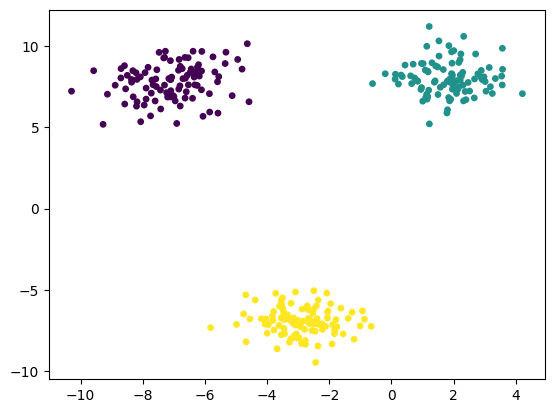

In [213]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=15)  # 根据y设置颜色，并将每个散点的大小设置为15
plt.show()

### 2.划分数据集

In [214]:
index = np.arange(20)
index

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [215]:
np.random.shuffle(index)
index

array([ 9,  5, 14, 18,  2, 19,  3,  1,  7, 12,  6, 17, 16, 13, 10,  4,  8,
        0, 15, 11])

In [216]:
np.random.permutation(index)
index

array([ 9,  5, 14, 18,  2, 19,  3,  1,  7, 12,  6, 17, 16, 13, 10,  4,  8,
        0, 15, 11])

In [217]:
np.random.seed(233)
shuffle = np.random.permutation(len(X))  # 将X的样本索引随机打乱
shuffle

array([ 23,  86, 204, 287, 206, 170, 234,  94, 146, 180, 263,  22,   3,
       264, 194, 290, 229, 177, 208, 202,  10, 188, 262, 120, 148, 121,
        98, 160, 267, 136, 294,   2,  34, 142, 271, 133, 127,  12,  29,
        49, 112, 218,  36,  57,  45,  11,  25, 151, 212, 289, 157,  19,
       275, 176, 144,  82, 161,  77,  51, 152, 135,  16,  65, 189, 298,
       279,  37, 187,  44, 210, 178, 165,   6, 162,  66,  32, 198,  43,
       108, 211,  67, 119, 284,  90,  89,  56, 217, 158, 228, 248, 191,
        47, 296, 123, 181, 200,  40,  87, 232,  97, 113, 122, 220, 153,
       173,  68,  99,  61, 273, 269, 281, 209,   4, 110, 259,  95, 205,
       288,   8, 283, 231, 291, 171, 111, 242, 216, 285,  54, 100,  38,
       185, 235, 174, 201, 107, 223, 222, 196, 268, 114, 147, 166,  85,
        39,  58, 256, 258,  74, 251,  15, 150, 137,  70,  91,  52,  14,
       169,  21, 184, 207, 238, 128, 219, 125, 293, 134,  27, 265,  96,
       270,  18, 109, 126, 203,  88, 249,  92, 213,  60, 227,   

In [218]:
shuffle.shape  # 查看索引数组的形状

(300,)

In [219]:
train_size = 0.7  # 设置训练集占全部数据的比例为 70%

In [220]:
train_index = shuffle[:int(len(X) * train_size)]  # 从打乱后的索引中，取前 70% 作为训练集索引

In [221]:
test_index = shuffle[int(len(X) * train_size):]  # 从打乱后的索引中，取剩余 30% 作为测试集索引

In [222]:
train_index.shape, test_index.shape  # 查看训练集索引和测试集索引的形状

((210,), (90,))

In [223]:
X[train_index].shape, y[train_index].shape

((210, 2), (210,))

In [224]:
X[test_index].shape, y[test_index].shape

((90, 2), (90,))

### 3.自定义训练集与测试集划分函数

In [225]:
def my_train_test_split(X, y, train_size=0.7, random_state=None):
    if random_state is not None:  # 设置随机种子，使每次划分结果一致
        np.random.seed(random_state)
    shuffle = np.random.permutation(len(X))  # 生成并随机打乱所有样本的索引
    train_index = shuffle[:int(len(X) * train_size)]  # 取前train_size比例的索引作为训练集索引
    test_index = shuffle[int(len(X) * train_size):]   # 取剩余索引作为测试集索引
    return X[train_index], X[test_index], y[train_index], y[test_index]  # 返回训练集特征、测试集特征、训练集标签和测试集标签

In [226]:
X_train, X_test, y_train, y_test = my_train_test_split(X,y,train_size=0.7,random_state=233)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((210, 2), (90, 2), (210,), (90,))

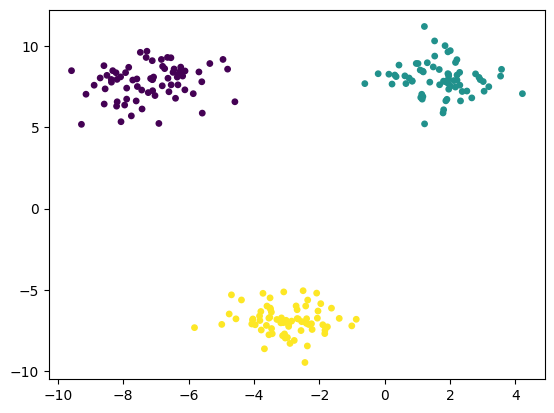

In [227]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=15)  # 绘制训练集散点图
plt.show()

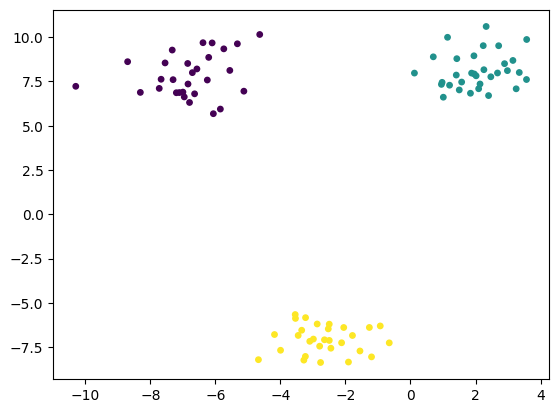

In [228]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=15)  # 绘制测试集散点图
plt.show()

### 4.scikit-learn中的KNN算法划分数据集

In [229]:
from sklearn.model_selection import train_test_split

In [230]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((210, 2), (90, 2), (210,), (90,))

In [231]:
from collections import Counter
Counter(y_test)

Counter({np.int64(2): 30, np.int64(0): 30, np.int64(1): 30})